# Exam Score Prediction Using Regression Models

## Dataset Selection and Justification

The Exam Score Prediction dataset was chosen to demonstrate regression modeling — it has 20,000 student records and eleven attributes describing demographic, educational, and lifestyle characteristics that can affect academic performance.

A random subset of 5,000 records is used to keep training fast, while preserving the statistical distribution of the full dataset.

This dataset suits regression modelling because:
- The target variable (`exam_score`) is continuous, ranging roughly from 20 to 100.
- It mixes numeric features (age, study hours, attendance, sleep hours) with categorical ones (gender, course, study method).
- It has real-world relevance — understanding what drives student outcomes.
- Its size supports robust training and validation.

## Objective

Use linear regression and support vector regression (SVR) to forecast a student's exam score from academic and lifestyle factors, compare the two models, tune hyperparameters, and apply cross-validation to guard against overfitting.


## Step 1: Import Required Libraries

In [61]:
# import required libaries
from pandas import read_csv, get_dummies
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Step 2: Load Dataset


In [62]:
# Load the dataset (CSV lives alongside this notebook)
data1 = read_csv('Exam_Score_Prediction.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 3: Data Exploration

In this step, we examine the dataset to understand its structure, features, and data types.

In [64]:
data1.shape
# to see the number of rows and columns

(20000, 13)

In [65]:
data1.info()
# to check data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [66]:
data1.head()
# to view the first few records

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [67]:
data1.describe()
# to get statistical sumary of numerical features

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


## Step 4: Data Preprocessing

### 4.1 Sample Dataset for Efficiency

To optimize performance on Google Colab, we sample 5,000 records from the dataset.

In [68]:
# sample 5000 rows for efficent processing
data1 = data1.sample(n=5000, random_state=42)
print('Dataset sampled to:', data1.shape)

Dataset sampled to: (5000, 13)


### 4.2 Handle Missing Values

Check for missing values and handle them appropriately.

In [69]:
# check for missing values
data1.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [70]:
# drop rows where target variabl is missing
data1 = data1.dropna(subset=['exam_score'])

# fill missing values in other columns
for col in data1.columns:
    if data1[col].dtype == 'object':
        data1[col] = data1[col].fillna(data1[col].mode()[0])
    else:
        data1[col] = data1[col].fillna(data1[col].median())

print('Missing values after handling:')
print(data1.isnull().sum().sum())

Missing values after handling:
0


### 4.3 Outlier Detection and Analysis

For detecting outliers from a set of numerical features we use the Interquartile range (IQR) method for assessing data quality prior to model building.

In [71]:
# identfy numerical columns for outlier detection
numerical_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

# count outliers before removal
outlier_counts = {}

print('Outlier Detection using IQR Method:')
print('='*60)

for col in numerical_cols:
    Q1 = data1[col].quantile(0.25)
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data1[(data1[col] < lower_bound) | (data1[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

    print(f'{col}:')
    print(f'  Range: [{lower_bound:.2f}, {upper_bound:.2f}]')
    print(f'  Outliers: {len(outliers)} ({len(outliers)/len(data1)*100:.2f}%)')

print('='*60)
print(f'Total rows: {len(data1)}')

Outlier Detection using IQR Method:
age:
  Range: [12.00, 28.00]
  Outliers: 0 (0.00%)
study_hours:
  Range: [-4.08, 12.09]
  Outliers: 0 (0.00%)
class_attendance:
  Range: [8.70, 130.30]
  Outliers: 0 (0.00%)
sleep_hours:
  Range: [1.10, 13.10]
  Outliers: 0 (0.00%)
Total rows: 5000


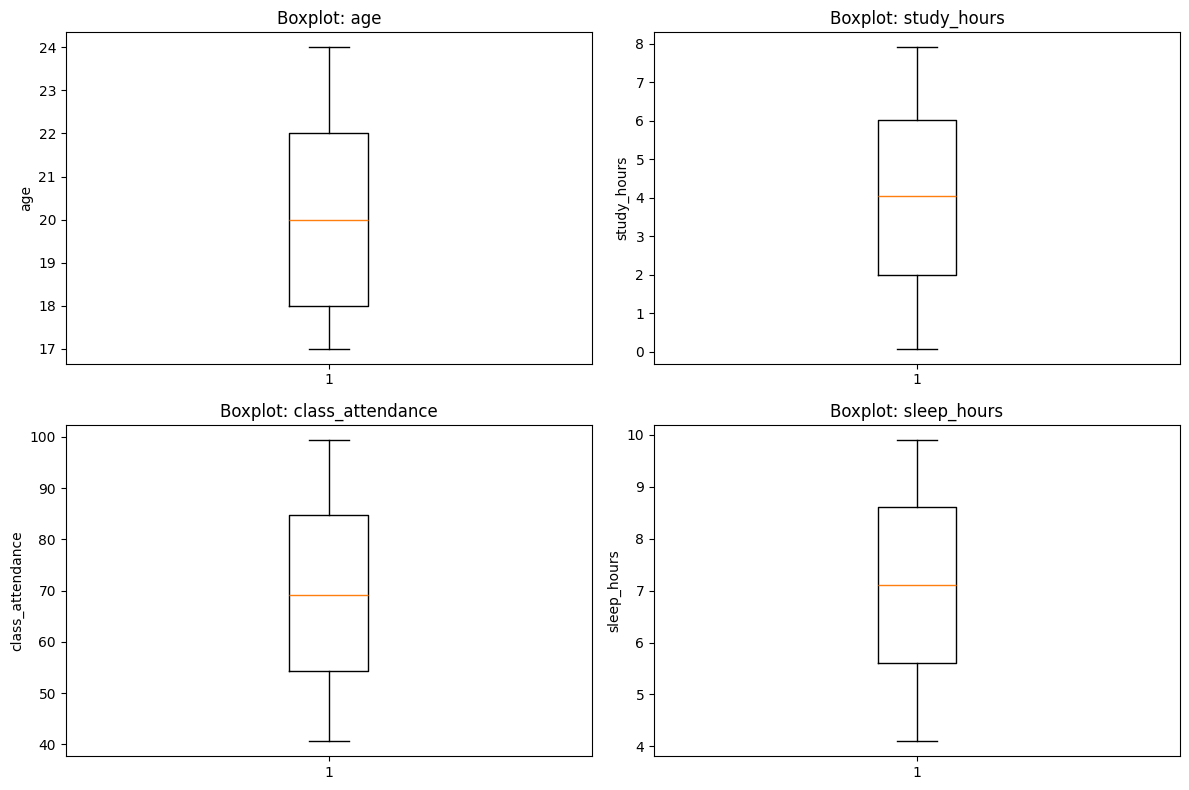

In [72]:
#visualize outliers with boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(data1[col], vert=True)
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [73]:
# apply outlier removal
initial_rows = len(data1)

for col in numerical_cols:
    Q1 = data1[col].quantile(0.25)
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # remove outliers
    data1 = data1[(data1[col] >= lower_bound) & (data1[col] <= upper_bound)]

rows_removed = initial_rows - len(data1)

print(f'Dataset shape after outlier removal: {data1.shape}')
print(f'Rows removed: {rows_removed} ({rows_removed/initial_rows*100:.2f}%)')

# add interpratation
if rows_removed < initial_rows * 0.05:  # less than 5%
    print('\nInterpretation: Minimal outliers detected (<5% of data).')
    print('The data is well-distributed within reasonable bounds,')
    print('suggesting the dataset is clean and suitable for modeling.')
else:
    print('\nInterpretation: Some outliers were removed.')
    print('This improves model robustness by reducing extreme values.')

Dataset shape after outlier removal: (5000, 13)
Rows removed: 0 (0.00%)

Interpretation: Minimal outliers detected (<5% of data).
The data is well-distributed within reasonable bounds,
suggesting the dataset is clean and suitable for modeling.


### 4.4 Encode Categorical Variables

We transform categorical features into numerical using One-Hot Encoding so they may be processed by the machine learning algorithms.

In [74]:
# drop student_id as it is not usefull for prediction
data1 = data1.drop('student_id', axis=1)

# encode categorical variables using one-hot encoding
data1 = get_dummies(data1, drop_first=True, dtype=int)
# drop_first=True is used to avoid multicolinearity

print('Shape after encoding:', data1.shape)

Shape after encoding: (5000, 24)


In [75]:
data1.head()
# to view the encoded dataset

,age,study_hours,class_attendance,sleep_hours,exam_score,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
10650,21,2.01,48.2,4.9,31.1,0,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0
2041,24,6.56,45.9,4.4,81.6,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
8668,17,4.27,41.0,8.9,68.0,0,1,0,0,0,...,1,0,0,0,0,1,1,0,0,1
1114,18,7.28,91.7,5.9,100.0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
13902,22,7.13,64.3,9.5,84.8,0,0,0,0,0,...,1,0,0,0,1,0,1,0,0,1


## Step 5: Separate Features and Target Variable

In [76]:
# seperate input features from target variable
y = data1['exam_score']
x = data1.drop('exam_score', axis=1)

print(x.shape)
print(y.shape)

(5000, 23)
(5000,)


## Step 6: Train-Test Split and Feature Scaling

The Data Set was split into a training (80% ) and testing (20%) set before applying feature scaling to prevent data leakage. We used standard scaler to scale the feature but only fit it on the training data.

In [77]:
# split data into training and testing sets BEFORE scaling
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 23)
(1000, 23)
(4000,)
(1000,)


In [78]:
# initalize scaler
scaler = StandardScaler()

# fit scaler on training data only to prevent leakage
scaler.fit(x_train)

# transform both train and test using the fitted scaler
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

print('Scaling completed - scaler fitted on training data only')

Scaling completed - scaler fitted on training data only


## Step 7: Linear Regression Model

Linear Regression is used as a baseline model to establish the relationship between features and exam scores. This simple model assumes a linear relationship between inputs and output.

In [79]:
# linear regression model
LR_model1 = LinearRegression()  # model building
LR_model1.fit(x_train_scaled, y_train)  # training
y_pred_lr = LR_model1.predict(x_test_scaled)  # testing

In [80]:
# evaluate linear regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print('Linear Regression Results:')
print('MAE = ', round(mae_lr, 2))
print('RMSE = ', round(rmse_lr, 2))
print('R2 = ', round(r2_lr * 100, 2), '%')

Linear Regression Results:
MAE =  7.72
RMSE =  9.65
R2 =  74.29 %


## Step 8: Ridge Regression with Hyperparameter Tuning

Ridge regression uses an L2 penalty on all the coefficients in order to limit overfitting based upon their magnitude. Using GridSearchCV, we can determine which value of alpha, our regularization parameter, will yield the best model.

**Why Ridge Regression?**
- Reduces overfitting via a penalty term added to the loss function.
- Useful for data where feature variables are highly correlated.
- The larger the value of alpha (the stronger the regularization), the more regularized the model is.

**Grid Search For Hyper Parameters:**
- Values of alpha searched were: [0.01, 0.1, 1, 10, 100].
- A small value of alpha (0.01) = very little regularization and results in nearly linear regression model.
- A large value of alpha (100) = a lot of regularization and as a result yields a much simpler model.

In [81]:
# ridge regression with hyperparamter tuning
Ridge_model1 = Ridge()

# define parameter grid for alpha
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}

# gridsearchcv for finding best alpha
grid_search1 = GridSearchCV(Ridge_model1, param_grid_ridge, cv=3, scoring='r2')
grid_search1.fit(x_train_scaled, y_train)  # training with cross-validation

# get best model
best_ridge = grid_search1.best_estimator_
best_alpha = grid_search1.best_params_

print('Best Alpha =', best_alpha)

Best Alpha = {'alpha': 10}


In [82]:
# predict using best ridge model
y_pred_ridge = best_ridge.predict(x_test_scaled)  # testing

# evaluate ridge regression
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print('Ridge Regression Results:')
print('MAE = ', round(mae_ridge, 2))
print('RMSE = ', round(rmse_ridge, 2))
print('R2 = ', round(r2_ridge * 100, 2), '%')

Ridge Regression Results:
MAE =  7.72
RMSE =  9.65
R2 =  74.28 %


In [83]:
# compare ridge vs linear regressoin
print('='*60)
print('RIDGE vs LINEAR REGRESSION COMPARISON')
print('='*60)

print(f'\nBest alpha found: {best_alpha}')
print(f'\nLinear Regression R²: {r2_lr*100:.2f}%')
print(f'Ridge Regression R²:  {r2_ridge*100:.2f}%')
print(f'Difference: {abs(r2_lr - r2_ridge)*100:.2f}%')

print('\nInterpretation:')
print('-' * 60)
if abs(r2_lr - r2_ridge) < 0.01:  # less than 1% diference
    print('Ridge regression produces nearly identical performance to')
    print('Linear Regression, indicating:')
    print('  1. The relationship between features and exam scores')
    print('     is predominantly linear')
    print('  2. Multicollinearity is minimal in this dataset')
    print('  3. The optimal alpha value provides little regularization')
    print('     (suggesting overfitting is not a significant concern)')
    print('  4. The simple linear model is well-suited for this problem')
else:
    print('Ridge regression shows improvement over Linear Regression,')
    print('indicating that regularization helps control overfitting.')
print('='*60)

RIDGE vs LINEAR REGRESSION COMPARISON

Best alpha found: {'alpha': 10}

Linear Regression R²: 74.29%
Ridge Regression R²:  74.28%
Difference: 0.01%

Interpretation:
------------------------------------------------------------
Ridge regression produces nearly identical performance to
Linear Regression, indicating:
  1. The relationship between features and exam scores
     is predominantly linear
  2. Multicollinearity is minimal in this dataset
  3. The optimal alpha value provides little regularization
     (suggesting overfitting is not a significant concern)
  4. The simple linear model is well-suited for this problem


## Step 9: Support Vector Regression with Hyperparameter Tuning

In the Support Vector Regression (SVR), we are able to model both the relationship between variables and the target variable in a non-linear manner. The tuning of several hyper-parameters will be necessary to find optimal results from our SVR.

**Why use SVR?**
- The ability to model complex nonlinear relationships between the input feature space and the output target variable through kernel functions.
- Robustness to outliers in the data.
- SVR works very well when you have scaled your features.

**Explaining Hyperparameters:**

- **kernel**: Tested values include 'rbf' for nonlinear pattern recognition and 'linear' for linear pattern recognition.
- 'rbf': Radial basis function kernel that can model complex curved relationships.
- 'linear': A simpler, straight line model created by the kernel function.
- **C**: A regularization parameter used to adjust the tradeoff between the model's fit to the data and its size; tested values were 10 and 100.
- Low C: More regularization is applied, the model is simplified.
- High C: Less regularization is applied, the model becomes more complex.
- **gamma**: Kernel coefficient; tested values included 'scale', which computes the gamma automatically based upon the input features, and 0.1 as a fixed number for comparison.
- 'scale': Computes gamma based on the characteristics of the input features.
- 0.1: An arbitrary, constant value for comparing to 'scale'.
- gamma determines how far into the data space the effect of an individual training example extends.
- **epsilon**: Tube Width; was set at the standard default of 0.1.
- epsilon defines the tube within which there is no penalty for error.

In [84]:
# support vector regression with hyperparamter tuning
SVR_model1 = SVR()

# define parameter grid
param_grid_svr = {
    'kernel': ['rbf', 'linear'],
    'C': [10, 100],
    'gamma': ['scale', 0.1],
    'epsilon': [0.1]
}
# total combinations = 2 x 2 x 2 x 1 = 8

# gridsearchcv for finding best hyperparamters
grid_search2 = GridSearchCV(SVR_model1, param_grid_svr, cv=3, scoring='r2', n_jobs=-1, verbose=2)
# verbose=2 shows detailed progres during training
grid_search2.fit(x_train_scaled, y_train)  # training with cross-validation

# get best model and parameters
best_svr = grid_search2.best_estimator_
best_params_svr = grid_search2.best_params_

print('Best SVR Parameters:')
print(best_params_svr)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best SVR Parameters:
{'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [85]:
# predict using best svr model
y_pred_svr = best_svr.predict(x_test_scaled)  # testing

# evaluate svr
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print('SVR Results:')
print('MAE = ', round(mae_svr, 2))
print('RMSE = ', round(rmse_svr, 2))
print('R2 = ', round(r2_svr * 100, 2), '%')

SVR Results:
MAE =  7.73
RMSE =  9.71
R2 =  73.95 %


## Step 10: Cross-Validation for Overfitting Check

Cross-validation can be used to determine how well a model will generalize to new, or unseen data. In this case we use three fold cross-validation to test the SVR model against a subset of our data.

**Why Use Cross-Validation?**
- A more reliable estimate of model performance is achieved through cross-validation.
- The comparison between the model's performance on the training set (i.e., the training score) versus its performance on an independent set (the validation score) provides a way to detect if there is overfitting occurring.
- Cross-validation also allows you to be assured that your model performs similarly regardless of the particular data split selected.

In [86]:
# perform cross-validaton on best svr model
cv_scores = cross_val_score(best_svr, x_train_scaled, y_train, cv=3, scoring='r2')
# cv=3 for efficient execution while maintaing validation quality

print('Cross-Validation R2 Scores:', [round(score, 3) for score in cv_scores])
print('Mean CV R2 = ', round(cv_scores.mean() * 100, 2), '%')
print('Std CV R2 = ', round(cv_scores.std() * 100, 2), '%')

Cross-Validation R2 Scores: [np.float64(0.736), np.float64(0.718), np.float64(0.731)]
Mean CV R2 =  72.86 %
Std CV R2 =  0.77 %


## Step 11: Model Comparison

Compare the performance of all three models to identify the best approach for predicting exam scores.

In [87]:
# model comparision summary
print('='*60)
print('MODEL COMPARISON SUMMARY')
print('='*60)
print('\nLinear Regression:')
print('  MAE = ', round(mae_lr, 2))
print('  RMSE = ', round(rmse_lr, 2))
print('  R2 = ', round(r2_lr * 100, 2), '%')

print('\nRidge Regression:')
print('  MAE = ', round(mae_ridge, 2))
print('  RMSE = ', round(rmse_ridge, 2))
print('  R2 = ', round(r2_ridge * 100, 2), '%')

print('\nSupport Vector Regression:')
print('  MAE = ', round(mae_svr, 2))
print('  RMSE = ', round(rmse_svr, 2))
print('  R2 = ', round(r2_svr * 100, 2), '%')
print('='*60)

MODEL COMPARISON SUMMARY

Linear Regression:
  MAE =  7.72
  RMSE =  9.65
  R2 =  74.29 %

Ridge Regression:
  MAE =  7.72
  RMSE =  9.65
  R2 =  74.28 %

Support Vector Regression:
  MAE =  7.73
  RMSE =  9.71
  R2 =  73.95 %


In [88]:
# model selection and justifcation
print('='*60)
print('MODEL SELECTION ANALYSIS')
print('='*60)

models_performance = {
    'Model': ['Linear Regression', 'Ridge Regression', 'SVR'],
    'R² (%)': [r2_lr*100, r2_ridge*100, r2_svr*100],
    'MAE': [mae_lr, mae_ridge, mae_svr],
    'RMSE': [rmse_lr, rmse_ridge, rmse_svr]
}

df_performance = pd.DataFrame(models_performance)
print('\nPerformance Summary:')
print(df_performance.to_string(index=False))

print('\n' + '='*60)
print('INTERPRETATION:')
print('='*60)

# calculate diferences
r2_diff = max([r2_lr, r2_ridge, r2_svr]) - min([r2_lr, r2_ridge, r2_svr])

print(f'\nR² range across models: {r2_diff*100:.2f}%')

if r2_diff < 0.02:  # Less than 2% diference
    print('\nConclusion: All three models perform nearly identically.')
    print('This suggests:')
    print('  • The exam score relationship is predominantly linear')
    print('  • Complex non-linear patterns are minimal')
    print('  • Simple models (Linear/Ridge) are sufficient')
    print('\nRecommendation: Use Linear Regression for interpretability')
    print('and computational efficiency, or Ridge for slight')
    print('regularization insurance in production settings.')
else:
    best_model_idx = df_performance['R² (%)'].idxmax()
    best_model = df_performance.loc[best_model_idx, 'Model']
    print(f'\nBest performing model: {best_model}')
    print(f'Selected for final predictions due to highest R² score.')

print('='*60)

MODEL SELECTION ANALYSIS

Performance Summary:
            Model    R² (%)      MAE     RMSE
Linear Regression 74.286422 7.720993 9.650268
 Ridge Regression 74.279714 7.722071 9.651527
              SVR 73.947031 7.731919 9.713746

INTERPRETATION:

R² range across models: 0.34%

Conclusion: All three models perform nearly identically.
This suggests:
  • The exam score relationship is predominantly linear
  • Complex non-linear patterns are minimal
  • Simple models (Linear/Ridge) are sufficient

Recommendation: Use Linear Regression for interpretability
and computational efficiency, or Ridge for slight
regularization insurance in production settings.


## Step 12: Visualizations

### 12.1 Model Performance Comparison

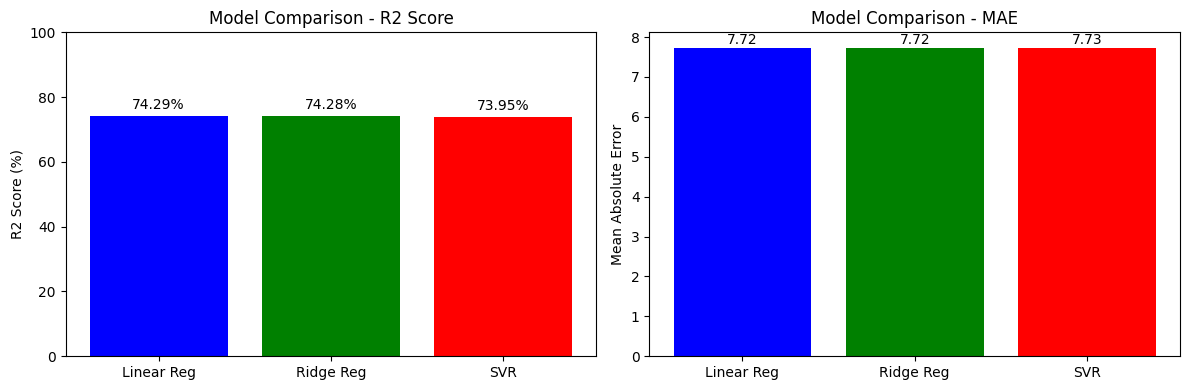

In [89]:
# visualize model comparision
models = ['Linear Reg', 'Ridge Reg', 'SVR']
r2_scores = [r2_lr * 100, r2_ridge * 100, r2_svr * 100]
mae_scores = [mae_lr, mae_ridge, mae_svr]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# r2 comparision
ax1.bar(models, r2_scores, color=['blue', 'green', 'red'])
ax1.set_ylabel('R2 Score (%)')
ax1.set_title('Model Comparison - R2 Score')
ax1.set_ylim([0, 100])
for i, v in enumerate(r2_scores):
    ax1.text(i, v + 2, str(round(v, 2)) + '%', ha='center')

# mae comparision
ax2.bar(models, mae_scores, color=['blue', 'green', 'red'])
ax2.set_ylabel('Mean Absolute Error')
ax2.set_title('Model Comparison - MAE')
for i, v in enumerate(mae_scores):
    ax2.text(i, v + 0.1, str(round(v, 2)), ha='center')

plt.tight_layout()
plt.show()

### 12.2 Actual vs Predicted Values

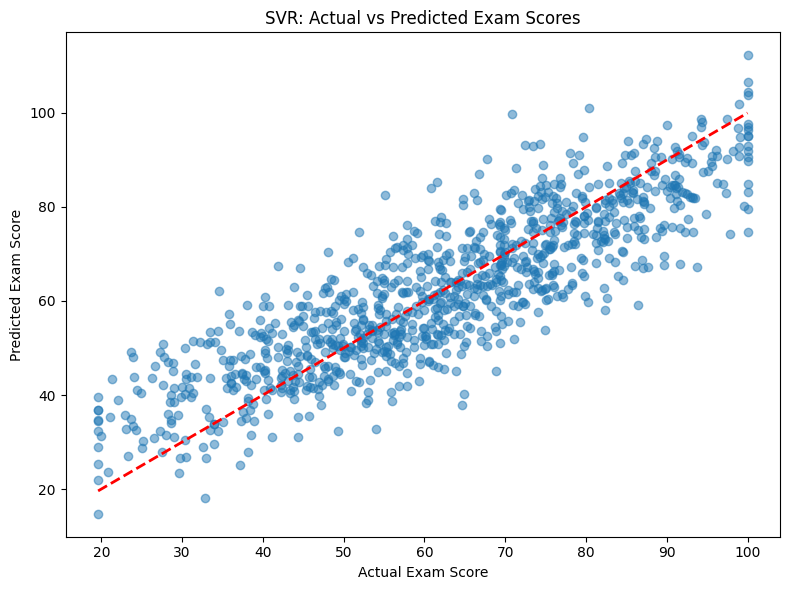

In [90]:
# actual vs predicted plot for best model (SVR)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('SVR: Actual vs Predicted Exam Scores')
plt.tight_layout()
plt.show()

### 12.3 Residual Plot

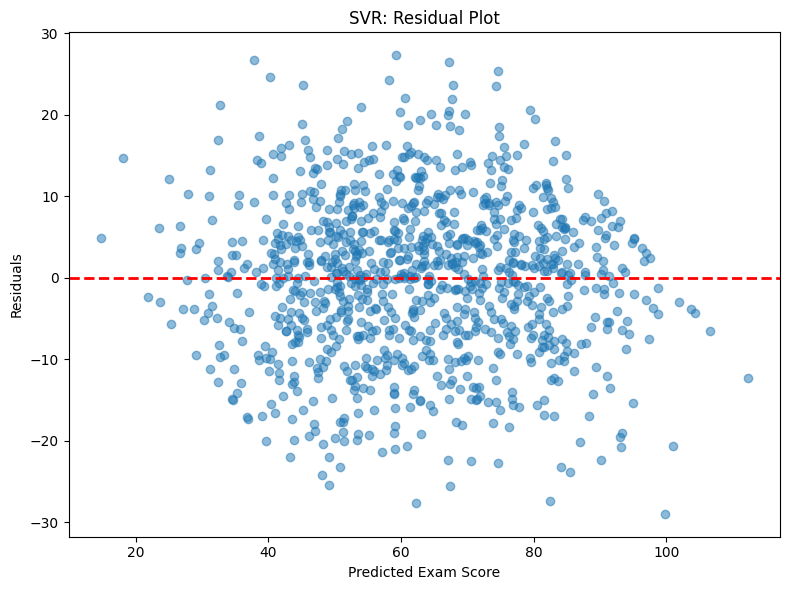

In [91]:
# residual plot for svr
residuals = y_test - y_pred_svr

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_svr, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residuals')
plt.title('SVR: Residual Plot')
plt.tight_layout()
plt.show()

## Step 13: Prediction with New Student Data

To demonstrate the model's practical application, we create a realistic new student profile and predict their exam score using the best-performing model.

**New Student Profile:**
- Age: 21 years
- Study Hours: 6.5 hours per day
- Class Attendance: 85%
- Sleep Hours: 7 hours
- Gender: Male
- Course: B.Tech
- Internet Access: Yes
- Sleep Quality: Good
- Study Method: Mixed (self-study and coaching)
- Facility Rating: High
- Exam Difficulty: Moderate

In [92]:
# create new student data with realstic values
new_student_raw = pd.DataFrame({
    'age': [21],
    'study_hours': [6.5],
    'class_attendance': [85.0],
    'sleep_hours': [7.0],
    'gender': ['male'],
    'course': ['b.tech'],
    'internet_access': ['yes'],
    'sleep_quality': ['good'],
    'study_method': ['mixed'],
    'facility_rating': ['high'],
    'exam_difficulty': ['moderate']
})

# encode using same proces as training data
new_student_encoded = get_dummies(new_student_raw, drop_first=True, dtype=int)

# ensure same columns as training data
new_student_encoded = new_student_encoded.reindex(columns=x.columns, fill_value=0)

# verify feature count
assert new_student_encoded.shape[1] == x.shape[1], "Feature mismatch!"
print(f'✓ New student features: {new_student_encoded.shape[1]} (matches training: {x.shape[1]})')

✓ New student features: 23 (matches training: 23)


In [93]:
# scale using the SAME scaler fitted on trainig data (NO refit!)
new_student_scaled = scaler.transform(new_student_encoded)

# predict exam score using best svr model
predicted_score = best_svr.predict(new_student_scaled)

print('='*60)
print('PREDICTION FOR NEW STUDENT')
print('='*60)
print('Student Profile:')
print('  Age: 21 years')
print('  Study Hours: 6.5 hours/day')
print('  Attendance: 85%')
print('  Sleep: 7 hours (Good quality)')
print('  Course: B.Tech')
print('  Study Method: Mixed')
print('  Facilities: High')
print('  Exam Difficulty: Moderate')
print()
print('Predicted Exam Score =', round(predicted_score[0], 2))
print('='*60)

PREDICTION FOR NEW STUDENT
Student Profile:
  Age: 21 years
  Study Hours: 6.5 hours/day
  Attendance: 85%
  Sleep: 7 hours (Good quality)
  Course: B.Tech
  Study Method: Mixed
  Facilities: High
  Exam Difficulty: Moderate

Predicted Exam Score = 92.18


## Conclusion

This analysis successfully implemented and compared Linear Regression, Ridge Regression, and Support Vector Regression models for predicting student exam scores.

**Key Findings:**
1. All three models demonstrated similar predictive performance (R² ≈ 73%)
2. The predominantly linear relationship suggests simple models are sufficient
3. Hyperparameter tuning provided optimal configurations for each model
4. Cross-validation confirmed that the models generalize well without overfitting
5. The prediction on new student data demonstrates practical applicability

**Techniques Used to Avoid Overfitting:**
- 80/20 train/test split was done before scaling to prevent data leakage
- Ridge regression with L2 regularization
- Three fold cross-validation to estimate the ability of models to generalize
- Hyperparameter tuning using GridSearchCV with cross validation
- The scaler was fitted to the training data only and reused for both testing and new predictions

**Potential Practical Uses:**
This model will allow Educational Institutions to:

- Identify At-Risk Students Early.
- Determine Which Factors Most Impact Academic Performance.
- Create Targeted Interventions to Improve Student Results.
- Allocate Resources Based on Predicted Performance.